## **CNN para classificação multiclasse de imagens**
## - Visualização dos filtros e dos *featuremaps*
**Dataset MNIST (Modified National Institute of Standards and Technology)**
- É considerado o dataset “hello world” de *computer vision*.
- Dataset de imagens de dígitos escritos manualmente
- Inputs: imagens de 28x28 pixeis
- Output: classe a representar o dígito (10 classes, dígitos 0-9)
- 70k imagens das quais 60k são para treino e 10k para teste
- 2 atributos: o id da imagem e o respetivo label   

Vamos utilizar uma rede neuronal para classificação do dígito em cada imagem de 28x28.

## imports

In [1]:
import sys
import subprocess
import importlib.util

def install_if_missing(import_name, package_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name or import_name])

install_if_missing("torch", "torch")
install_if_missing("torchvision", "torchvision")
install_if_missing("torchinfo", "torchinfo")
install_if_missing("livelossplot", "livelossplot")
install_if_missing("sklearn", "scikit-learn")
install_if_missing("seaborn", "seaborn")
install_if_missing("pandas", "pandas")
install_if_missing("numpy", "numpy")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("gdown", "gdown")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn import Module, Sequential, Conv2d, ReLU, MaxPool2d, Linear, Softmax, BatchNorm2d, Dropout
from torch.utils.data import DataLoader, Dataset, random_split

from torchvision import datasets, transforms
from torchvision.transforms import Compose, ToTensor, Normalize

from torchinfo import summary
from livelossplot import PlotLosses

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("torch:", torch.__version__)
print("cuda disponível:", torch.cuda.is_available())


torch: 2.11.0+cpu
cuda disponível: False


In [2]:
PATH = './'
PATH_TRAIN = './mnist_train.csv'
PATH_TEST = './mnist_test.csv'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_default_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device

    def __iter__(self):
        for batch in self.dataloader:
            yield to_device(batch, self.device)

    def __len__(self):
        return len(self.dataloader)

device = get_default_device()
print(device)


cpu


## 1. Preparar os Dados

In [4]:
train_transform = Compose([
    ToTensor(),
    Normalize((0.1307,), (0.3081,))
])

test_transform = Compose([
    ToTensor(),
    Normalize((0.1307,), (0.3081,))
])


In [5]:
class CSVDataset(Dataset):

    def __init__(self, path, transform=None):
        df = pd.read_csv(path)
        self.labels = torch.tensor(df.iloc[:, 0].values, dtype=torch.long)
        self.images = torch.tensor(df.iloc[:, 1:].values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_TensorDataset(self):
        return self.images, self.labels


def prepare_data_loaders(path_train, path_test):
    train_full = CSVDataset(path_train, transform=None)
    test_dataset = CSVDataset(path_test, transform=None)

    val_size = int(len(train_full) * 0.2)
    train_size = len(train_full) - val_size
    train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

    train_dl_raw = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_dl_raw   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
    test_dl_raw  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

    train_dl = DeviceDataLoader(train_dl_raw, device)
    val_dl   = DeviceDataLoader(val_dl_raw,   device)
    test_dl  = DeviceDataLoader(test_dl_raw,  device)

    return train_dl, val_dl, test_dl, train_dl_raw, val_dl_raw, test_dl_raw


train_dl, val_dl, test_dl, train_dl_all, val_dl_all, test_dl_all = prepare_data_loaders(PATH_TRAIN, PATH_TEST)
print("Nº batches treino   :", len(train_dl))
print("Nº batches validação:", len(val_dl))
print("Nº batches teste    :", len(test_dl))


Nº batches treino   : 1500
Nº batches validação: 375
Nº batches teste    : 313


## 1.1 Visualizar os Dados

In [6]:
def output_label(label, mapping='label'):
    labels = {
        0: "zero", 1: "um",   2: "dois",   3: "três",   4: "quatro",
        5: "cinco",6: "seis", 7: "sete",   8: "oito",   9: "nove"
    }
    label = int(label)
    if mapping == 'label':
        return label
    return labels[label]

list_classes = [output_label(i, mapping='extenso') for i in range(10)]
print(list_classes)


['zero', 'um', 'dois', 'três', 'quatro', 'cinco', 'seis', 'sete', 'oito', 'nove']


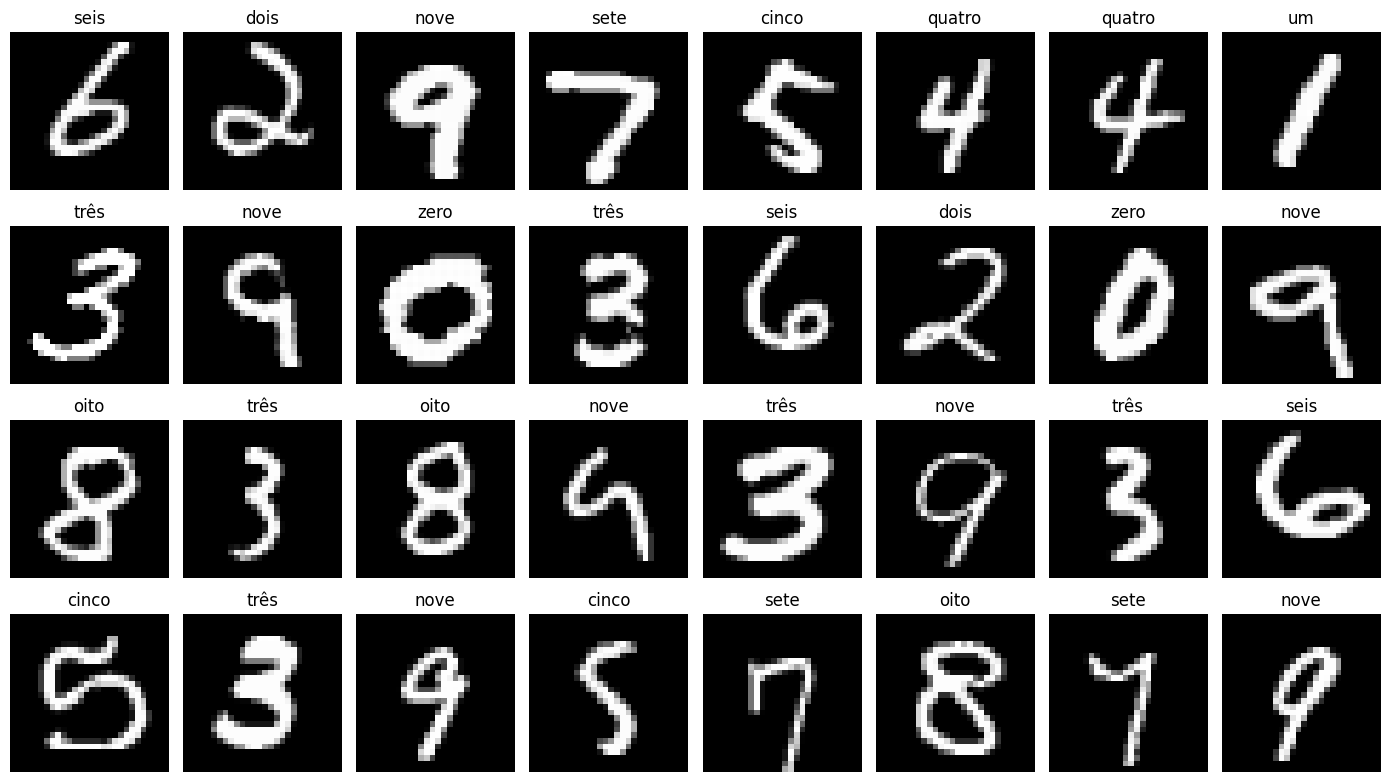

In [7]:
def visualize_mnist_images(dl):
    imagens, labels = next(iter(dl))
    imagens = imagens.cpu()
    labels  = labels.cpu()

    n_cols = 8
    n_rows = 4
    plt.figure(figsize=(14, 2 * n_rows))
    for i in range(min(32, len(imagens))):
        plt.subplot(n_rows, n_cols, i + 1)
        img = imagens[i, 0]
        plt.imshow(img, cmap="gray")
        plt.title(output_label(labels[i].item(), mapping='extenso'))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_mnist_images(train_dl_all)


## 2. Definir o Modelo

In [8]:
class CNNModel_1(Module):
    def __init__(self):
        super().__init__()
        self.layer1 = Sequential(
            Conv2d(1, 32, kernel_size=3, stride=1),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = Sequential(
            Conv2d(32, 32, kernel_size=3, stride=1),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc1  = Linear(32 * 5 * 5, 100)
        self.act1 = ReLU()
        self.fc2  = Linear(100, 10)
        self.act2 = Softmax(dim=1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return x

model = CNNModel_1()
print(summary(model, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel_1                               [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 13, 13]          --
│    └─Conv2d: 2-1                       [32, 32, 26, 26]          320
│    └─ReLU: 2-2                         [32, 32, 26, 26]          --
│    └─MaxPool2d: 2-3                    [32, 32, 13, 13]          --
├─Sequential: 1-2                        [32, 32, 5, 5]            --
│    └─Conv2d: 2-4                       [32, 32, 11, 11]          9,248
│    └─ReLU: 2-5                         [32, 32, 11, 11]          --
│    └─MaxPool2d: 2-6                    [32, 32, 5, 5]            --
├─Linear: 1-3                            [32, 100]                 80,100
├─ReLU: 1-4                              [32, 100]                 --
├─Linear: 1-5                            [32, 10]                  1,010
├─Softmax: 1-6                           [32, 10]                  --
Tota

In [9]:
class CNNModel_2(Module):
    def __init__(self):
        super().__init__()
        self.layer1 = Sequential(
            Conv2d(1, 32, kernel_size=3, stride=1),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = Sequential(
            Conv2d(32, 32, kernel_size=3, stride=1),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc1 = Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = CNNModel_2()
print(summary(model, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel_2                               [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 13, 13]          --
│    └─Conv2d: 2-1                       [32, 32, 26, 26]          320
│    └─ReLU: 2-2                         [32, 32, 26, 26]          --
│    └─MaxPool2d: 2-3                    [32, 32, 13, 13]          --
├─Sequential: 1-2                        [32, 32, 5, 5]            --
│    └─Conv2d: 2-4                       [32, 32, 11, 11]          9,248
│    └─ReLU: 2-5                         [32, 32, 11, 11]          --
│    └─MaxPool2d: 2-6                    [32, 32, 5, 5]            --
├─Linear: 1-3                            [32, 10]                  8,010
Total params: 17,578
Trainable params: 17,578
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.99
Input size (MB): 0.10
Forward/backward pass size (MB): 6.53
Params size (MB): 0.07
Estimated Total Size (MB

In [10]:
class CNNModel_3(Module):
    def __init__(self):
        super().__init__()
        self.layer1 = Sequential(
            Conv2d(1, 32, kernel_size=3, stride=1),
            BatchNorm2d(32),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = Sequential(
            Conv2d(32, 32, kernel_size=3, stride=1),
            BatchNorm2d(32),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc1     = Linear(32 * 5 * 5, 128)
        self.dropout = Dropout(p=0.5)
        self.fc2     = Linear(128, 64)
        self.fc3     = Linear(64, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = CNNModel_3()
print(summary(model, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel_3                               [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 13, 13]          --
│    └─Conv2d: 2-1                       [32, 32, 26, 26]          320
│    └─BatchNorm2d: 2-2                  [32, 32, 26, 26]          64
│    └─ReLU: 2-3                         [32, 32, 26, 26]          --
│    └─MaxPool2d: 2-4                    [32, 32, 13, 13]          --
├─Sequential: 1-2                        [32, 32, 5, 5]            --
│    └─Conv2d: 2-5                       [32, 32, 11, 11]          9,248
│    └─BatchNorm2d: 2-6                  [32, 32, 11, 11]          64
│    └─ReLU: 2-7                         [32, 32, 11, 11]          --
│    └─MaxPool2d: 2-8                    [32, 32, 5, 5]            --
├─Linear: 1-3                            [32, 128]                 102,528
├─Dropout: 1-4                           [32, 128]                 --
├─Line

In [11]:
class CNNModel_4(Module):
    def __init__(self):
        super().__init__()
        self.layer1 = Sequential(
            Conv2d(1, 32, kernel_size=3, stride=1),
            BatchNorm2d(32),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2),
            Dropout(p=0.25)
        )
        self.layer2 = Sequential(
            Conv2d(32, 32, kernel_size=3, stride=1),
            BatchNorm2d(32),
            ReLU(),
            MaxPool2d(kernel_size=2, stride=2),
            Dropout(p=0.25)
        )
        self.fc1 = Linear(32 * 5 * 5, 128)
        self.fc2 = Linear(128, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNModel_4()
print(summary(model, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel_4                               [32, 10]                  --
├─Sequential: 1-1                        [32, 32, 13, 13]          --
│    └─Conv2d: 2-1                       [32, 32, 26, 26]          320
│    └─BatchNorm2d: 2-2                  [32, 32, 26, 26]          64
│    └─ReLU: 2-3                         [32, 32, 26, 26]          --
│    └─MaxPool2d: 2-4                    [32, 32, 13, 13]          --
│    └─Dropout: 2-5                      [32, 32, 13, 13]          --
├─Sequential: 1-2                        [32, 32, 5, 5]            --
│    └─Conv2d: 2-6                       [32, 32, 11, 11]          9,248
│    └─BatchNorm2d: 2-7                  [32, 32, 11, 11]          64
│    └─ReLU: 2-8                         [32, 32, 11, 11]          --
│    └─MaxPool2d: 2-9                    [32, 32, 5, 5]            --
│    └─Dropout: 2-10                     [32, 32, 5, 5]            --
├─Linear: 1

## 3. Treinar o Modelo

In [12]:
def train_model(model_path, train_dl, val_dl, model, criterion, optimizer, epochs):
    history = []
    plotlosses = PlotLosses()

    for epoch in range(epochs):
        # --- treino ---
        model.train()
        train_losses, train_accs = [], []
        for images, labels in train_dl:
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, dim=1)
            acc = (preds == labels).float().mean()
            train_losses.append(loss.item())
            train_accs.append(acc.item())

        # --- validação ---
        model.eval()
        val_losses, val_accs = [], []
        with torch.no_grad():
            for images, labels in val_dl:
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, dim=1)
                acc = (preds == labels).float().mean()
                val_losses.append(loss.item())
                val_accs.append(acc.item())

        t_loss = sum(train_losses) / len(train_losses)
        t_acc  = sum(train_accs)  / len(train_accs)
        v_loss = sum(val_losses)  / len(val_losses)
        v_acc  = sum(val_accs)    / len(val_accs)

        history.append({"train_loss": t_loss, "train_acc": t_acc,
                        "val_loss":   v_loss, "val_acc":   v_acc})

        plotlosses.update({"loss": t_loss, "val_loss": v_loss,
                           "accuracy": t_acc, "val_accuracy": v_acc})
        plotlosses.send()

        print(f"Epoch {epoch+1:03d}/{epochs} | train_loss={t_loss:.4f} | train_acc={t_acc:.4f} | val_loss={v_loss:.4f} | val_acc={v_acc:.4f}")

    torch.save(model, model_path)
    print("Modelo guardado em:", model_path)
    return history


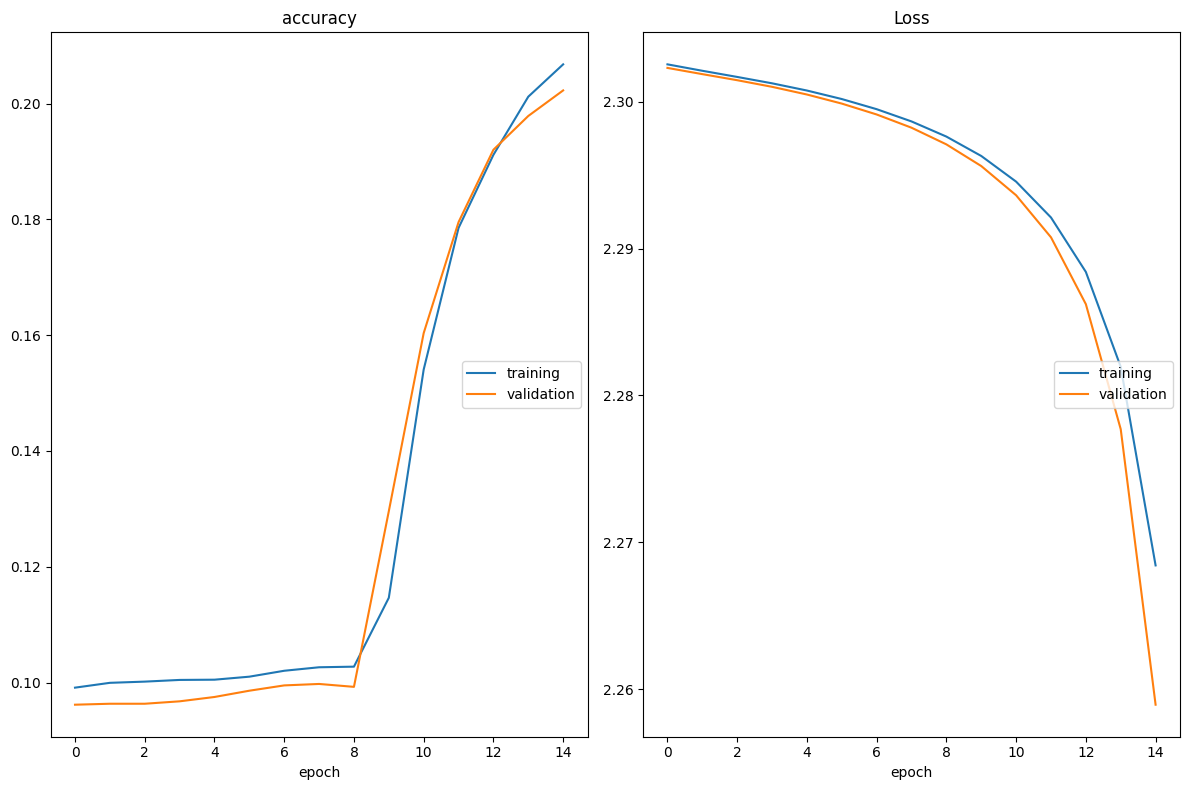

accuracy
	training         	 (min:    0.099, max:    0.207, cur:    0.207)
	validation       	 (min:    0.096, max:    0.202, cur:    0.202)
Loss
	training         	 (min:    2.268, max:    2.303, cur:    2.268)
	validation       	 (min:    2.259, max:    2.302, cur:    2.259)
Epoch 015/15 | train_loss=2.2684 | train_acc=0.2068 | val_loss=2.2589 | val_acc=0.2023
Modelo guardado em: CNNModel_1.pth


In [13]:
######### CNNModel_1 ################
model_1 = CNNModel_1().to(device)
print(summary(model_1, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_1.parameters(), lr=0.001)
history_1 = train_model('CNNModel_1.pth', train_dl, val_dl, model_1, criterion, optimizer, epochs=15)


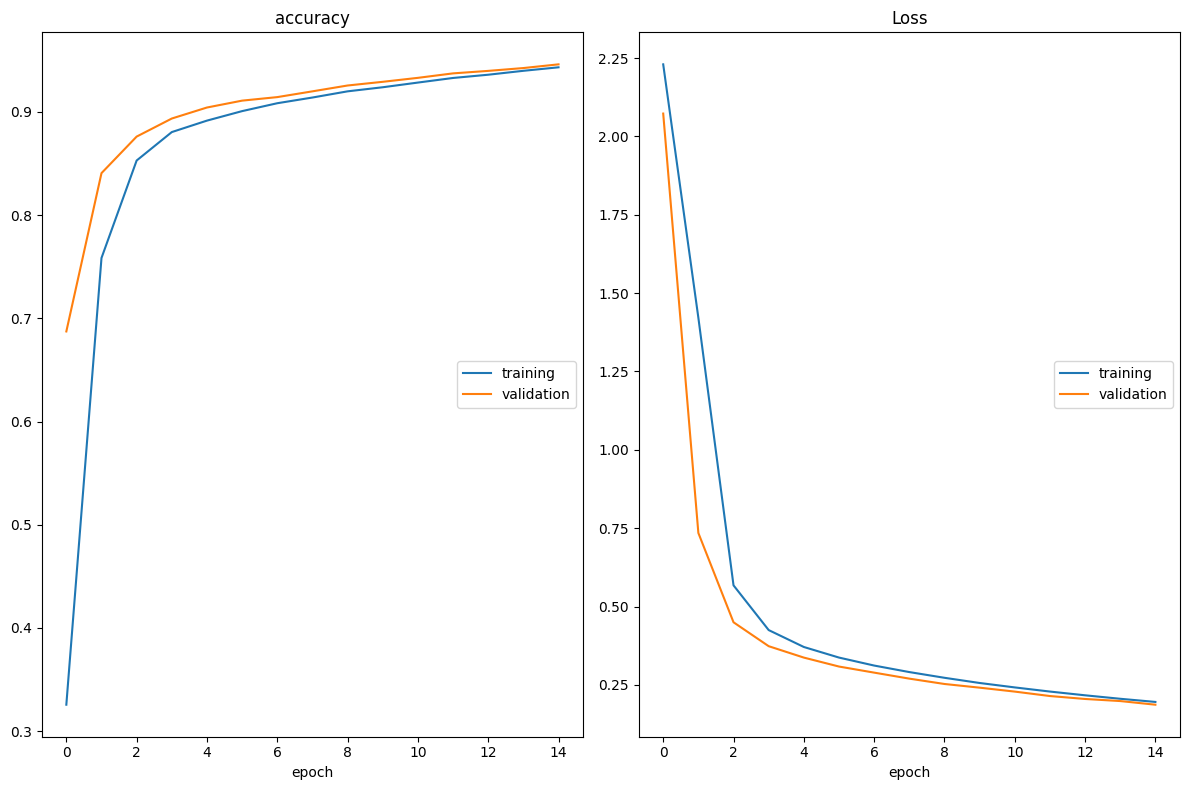

accuracy
	training         	 (min:    0.326, max:    0.943, cur:    0.943)
	validation       	 (min:    0.687, max:    0.946, cur:    0.946)
Loss
	training         	 (min:    0.196, max:    2.230, cur:    0.196)
	validation       	 (min:    0.187, max:    2.073, cur:    0.187)
Epoch 015/15 | train_loss=0.1955 | train_acc=0.9433 | val_loss=0.1867 | val_acc=0.9462
Modelo guardado em: CNNModel_2.pth


In [14]:
######### CNNModel_2 ################
model_2 = CNNModel_2().to(device)
print(summary(model_2, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_2.parameters(), lr=0.001)
history_2 = train_model('CNNModel_2.pth', train_dl, val_dl, model_2, criterion, optimizer, epochs=15)


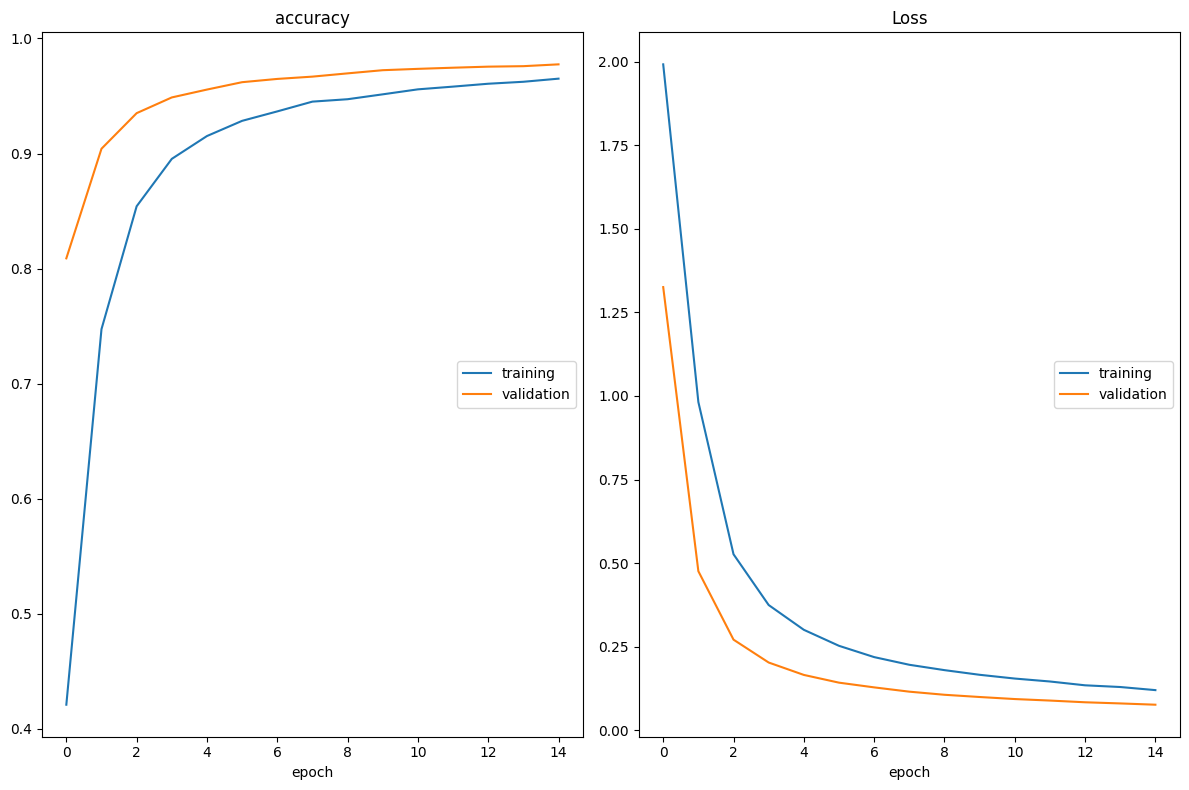

accuracy
	training         	 (min:    0.421, max:    0.965, cur:    0.965)
	validation       	 (min:    0.809, max:    0.977, cur:    0.977)
Loss
	training         	 (min:    0.121, max:    1.992, cur:    0.121)
	validation       	 (min:    0.077, max:    1.326, cur:    0.077)
Epoch 015/15 | train_loss=0.1205 | train_acc=0.9651 | val_loss=0.0769 | val_acc=0.9775
Modelo guardado em: CNNModel_3.pth


In [15]:
######### CNNModel_3 ################
model_3 = CNNModel_3().to(device)
print(summary(model_3, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_3.parameters(), lr=0.001)
history_3 = train_model('CNNModel_3.pth', train_dl, val_dl, model_3, criterion, optimizer, epochs=15)


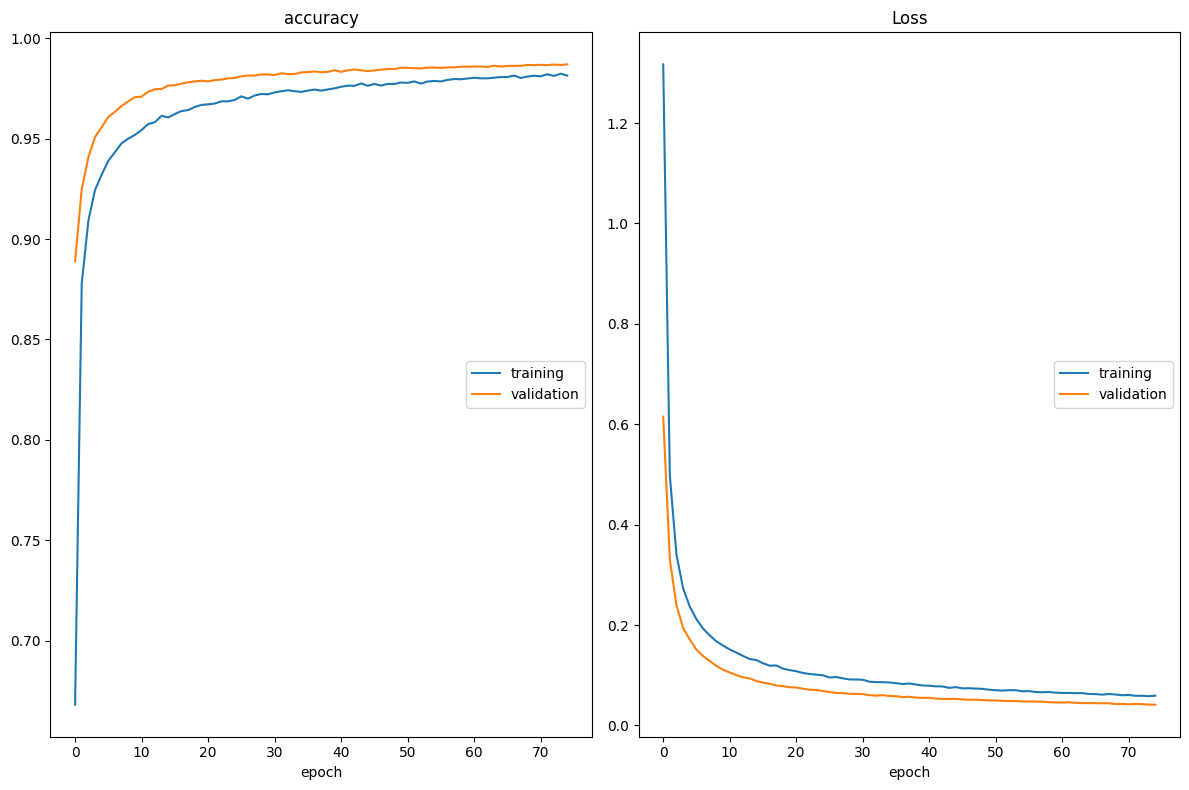

accuracy
	training         	 (min:    0.668, max:    0.982, cur:    0.981)
	validation       	 (min:    0.889, max:    0.987, cur:    0.987)
Loss
	training         	 (min:    0.058, max:    1.317, cur:    0.059)
	validation       	 (min:    0.041, max:    0.615, cur:    0.041)
Epoch 075/75 | train_loss=0.0594 | train_acc=0.9814 | val_loss=0.0414 | val_acc=0.9870
Modelo guardado em: CNNModel_4.pth


In [16]:
######### CNNModel_4 ################
model_4 = CNNModel_4().to(device)
print(summary(model_4, input_size=(BATCH_SIZE, 1, 28, 28), verbose=0))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_4.parameters(), lr=0.001)
history_4 = train_model('CNNModel_4.pth', train_dl, val_dl, model_4, criterion, optimizer, epochs=75)


## 4. Avaliar o Modelo

CNNModel_1
Accuracy teste: 0.2098
              precision    recall  f1-score   support

        zero       0.12      1.00      0.21       980
          um       0.62      0.99      0.76      1135
        dois       0.00      0.00      0.00      1032
        três       0.00      0.00      0.00      1010
      quatro       0.00      0.00      0.00       982
       cinco       0.00      0.00      0.00       892
        seis       0.00      0.00      0.00       958
        sete       0.00      0.00      0.00      1027
        oito       0.00      0.00      0.00       974
        nove       0.00      0.00      0.00      1009

    accuracy                           0.21      9999
   macro avg       0.07      0.20      0.10      9999
weighted avg       0.08      0.21      0.11      9999



c:\Users\FernandoPires\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FernandoPires\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FernandoPires\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

,real,real_extenso,previsto,previsto_extenso,correto
0,2,dois,0,zero,False
1,1,um,1,um,True
2,0,zero,0,zero,True
3,4,quatro,0,zero,False
4,1,um,1,um,True
5,4,quatro,0,zero,False
6,9,nove,0,zero,False
7,5,cinco,0,zero,False
8,9,nove,0,zero,False
9,0,zero,0,zero,True


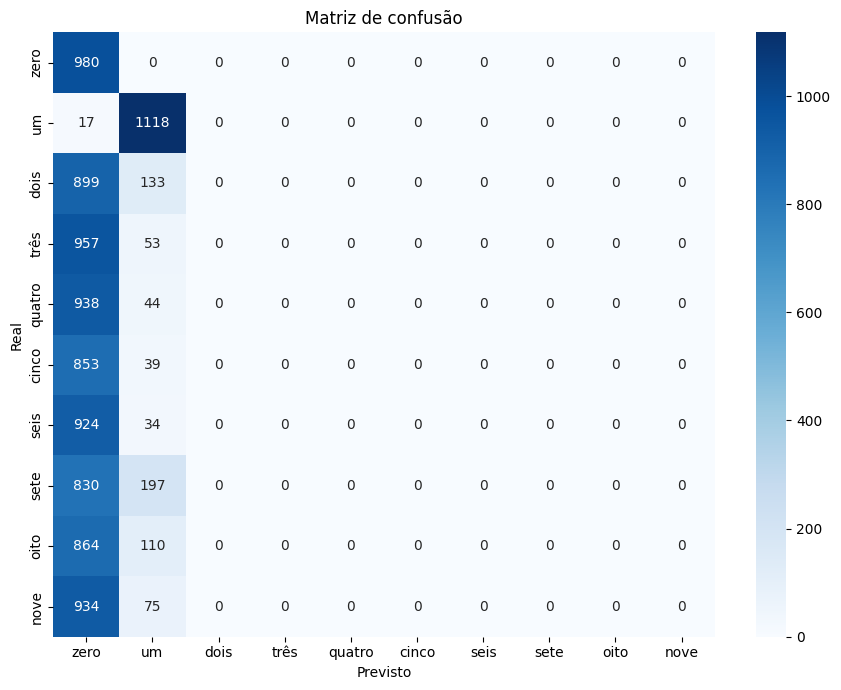

CNNModel_2
Accuracy teste: 0.9500
              precision    recall  f1-score   support

        zero       0.94      0.99      0.97       980
          um       0.98      0.98      0.98      1135
        dois       0.94      0.94      0.94      1032
        três       0.94      0.95      0.94      1010
      quatro       0.97      0.96      0.96       982
       cinco       0.95      0.94      0.94       892
        seis       0.94      0.96      0.95       958
        sete       0.96      0.93      0.95      1027
        oito       0.94      0.91      0.93       974
        nove       0.93      0.93      0.93      1009

    accuracy                           0.95      9999
   macro avg       0.95      0.95      0.95      9999
weighted avg       0.95      0.95      0.95      9999



,real,real_extenso,previsto,previsto_extenso,correto
0,2,dois,2,dois,True
1,1,um,1,um,True
2,0,zero,0,zero,True
3,4,quatro,4,quatro,True
4,1,um,1,um,True
5,4,quatro,4,quatro,True
6,9,nove,9,nove,True
7,5,cinco,6,seis,False
8,9,nove,9,nove,True
9,0,zero,0,zero,True


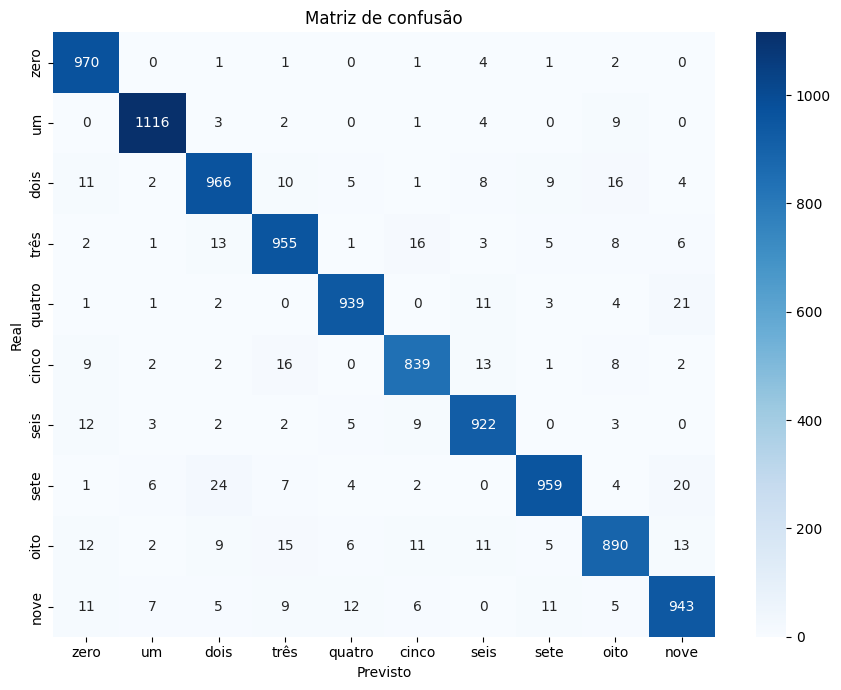

CNNModel_3
Accuracy teste: 0.9790
              precision    recall  f1-score   support

        zero       0.98      0.99      0.98       980
          um       0.99      0.99      0.99      1135
        dois       0.97      0.97      0.97      1032
        três       0.99      0.98      0.98      1010
      quatro       0.98      0.98      0.98       982
       cinco       0.98      0.98      0.98       892
        seis       0.98      0.99      0.98       958
        sete       0.97      0.97      0.97      1027
        oito       0.98      0.98      0.98       974
        nove       0.98      0.96      0.97      1009

    accuracy                           0.98      9999
   macro avg       0.98      0.98      0.98      9999
weighted avg       0.98      0.98      0.98      9999



,real,real_extenso,previsto,previsto_extenso,correto
0,2,dois,2,dois,True
1,1,um,1,um,True
2,0,zero,0,zero,True
3,4,quatro,4,quatro,True
4,1,um,1,um,True
5,4,quatro,4,quatro,True
6,9,nove,9,nove,True
7,5,cinco,5,cinco,True
8,9,nove,9,nove,True
9,0,zero,0,zero,True


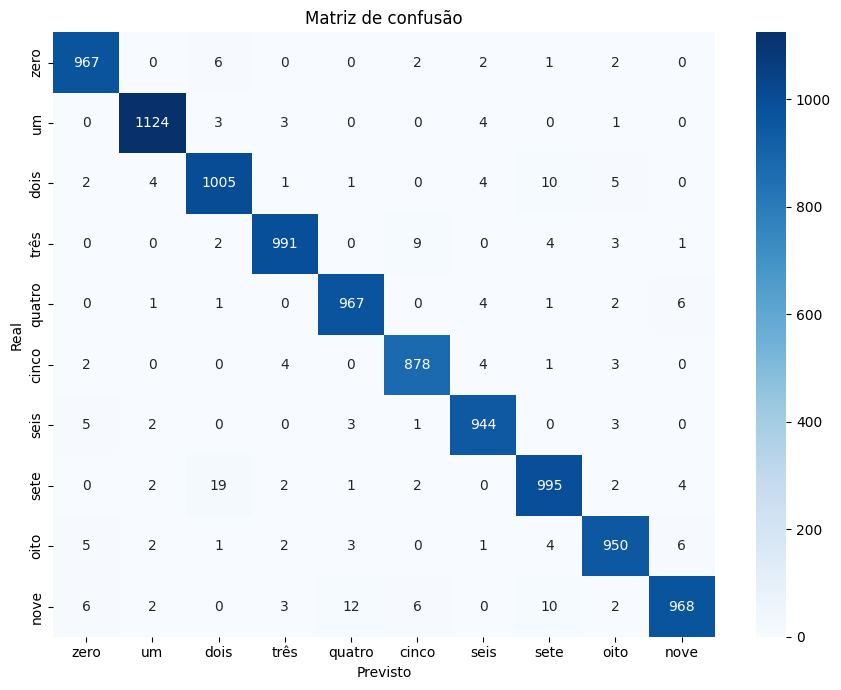

CNNModel_4
Accuracy teste: 0.9884
              precision    recall  f1-score   support

        zero       0.98      1.00      0.99       980
          um       0.99      1.00      0.99      1135
        dois       0.99      0.99      0.99      1032
        três       0.99      0.99      0.99      1010
      quatro       0.99      0.99      0.99       982
       cinco       0.99      0.99      0.99       892
        seis       1.00      0.99      0.99       958
        sete       0.98      0.98      0.98      1027
        oito       0.99      0.98      0.99       974
        nove       0.99      0.98      0.98      1009

    accuracy                           0.99      9999
   macro avg       0.99      0.99      0.99      9999
weighted avg       0.99      0.99      0.99      9999



,real,real_extenso,previsto,previsto_extenso,correto
0,2,dois,2,dois,True
1,1,um,1,um,True
2,0,zero,0,zero,True
3,4,quatro,4,quatro,True
4,1,um,1,um,True
5,4,quatro,4,quatro,True
6,9,nove,9,nove,True
7,5,cinco,5,cinco,True
8,9,nove,9,nove,True
9,0,zero,0,zero,True


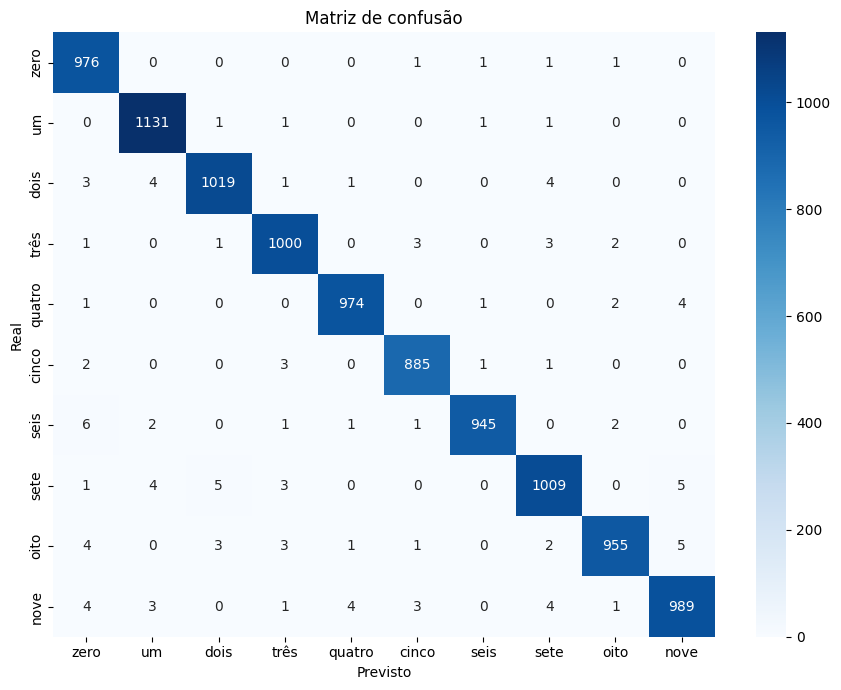

In [17]:
def evaluate_model(test_dl, model):
    model.eval()
    actual_values = []
    predictions   = []

    with torch.no_grad():
        for images, labels in test_dl:
            outputs = model(images)
            _, preds = torch.max(outputs, dim=1)
            actual_values.extend(labels.detach().cpu().numpy().tolist())
            predictions.extend(preds.detach().cpu().numpy().tolist())

    acc = accuracy_score(actual_values, predictions)
    cm  = confusion_matrix(actual_values, predictions)
    return actual_values, predictions, cm, acc


def display_predictions(actual_values, predictions):
    df = pd.DataFrame({
        "real":             actual_values[:30],
        "real_extenso":     [output_label(x, 'extenso') for x in actual_values[:30]],
        "previsto":         predictions[:30],
        "previsto_extenso": [output_label(x, 'extenso') for x in predictions[:30]],
        "correto":          [a == p for a, p in zip(actual_values[:30], predictions[:30])]
    })
    display(df)


def display_confusion_matrix(cm, list_classes):
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list_classes, yticklabels=list_classes)
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title("Matriz de confusão")
    plt.tight_layout()
    plt.show()


for model_name, model in [("CNNModel_1", model_1), ("CNNModel_2", model_2),
                           ("CNNModel_3", model_3), ("CNNModel_4", model_4)]:
    print("=" * 80)
    print(model_name)
    actual_values, predictions, cm, acc = evaluate_model(test_dl, model)
    print(f"Accuracy teste: {acc:.4f}")
    print(classification_report(actual_values, predictions, target_names=list_classes))
    display_predictions(actual_values, predictions)
    display_confusion_matrix(cm, list_classes)


## 5. Usar o Modelo

torch.Size([1, 1, 28, 28])
torch.float32


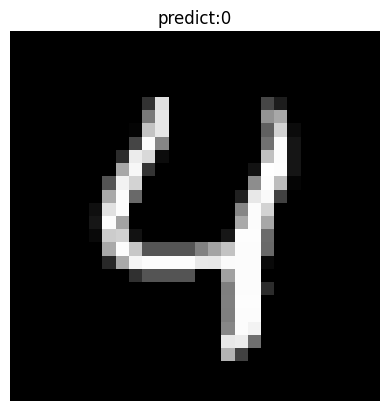

np.int64(0)

In [20]:
def img_show(img, legenda):
    img = img.cpu()
    plt.axis('off')
    plt.title(legenda)
    plt.grid(False)
    plt.imshow(img[0, 0], cmap=plt.get_cmap('gray'))
    plt.show()


def make_prediction(model, img):
    img = img.reshape(1, 1, 28, 28)
    print(img.shape)
    print(img.dtype)
    img = img.to(device)
    prediction = model(img).cpu().detach().numpy()[0].argmax()
    legenda = f"predict:{prediction}"
    img_show(img, legenda)
    return prediction


model = torch.load('CNNModel_1.pth', map_location=device, weights_only=False)
model.eval()
imagens, label = next(iter(test_dl))
make_prediction(model, imagens[3])


torch.Size([1, 1, 28, 28])
torch.float32


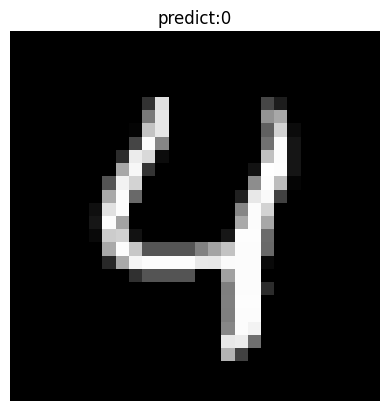

pred: 0
0
CNNModel_1(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=800, out_features=100, bias=True)
  (act1): ReLU()
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (act2): Softmax(dim=1)
)


In [22]:
def show_batch_images(model, dataloader, num_image):
    imagens, label = next(iter(test_dl))
    pred = make_prediction(model, imagens[3])
    print("pred:", pred)
    return imagens, pred


model = torch.load('CNNModel_1.pth', map_location=device, weights_only=False)
model.eval()
images, pred = show_batch_images(model, test_dl, 1)
print(pred)
print(model)


In [23]:
# Visualizar os parâmetros do modelo por camadas
for name, param in model.named_parameters():
    print(f"{name:40s} | shape={tuple(param.shape)} | requires_grad={param.requires_grad}")


layer1.0.weight                          | shape=(32, 1, 3, 3) | requires_grad=True
layer1.0.bias                            | shape=(32,) | requires_grad=True
layer2.0.weight                          | shape=(32, 32, 3, 3) | requires_grad=True
layer2.0.bias                            | shape=(32,) | requires_grad=True
fc1.weight                               | shape=(100, 800) | requires_grad=True
fc1.bias                                 | shape=(100,) | requires_grad=True
fc2.weight                               | shape=(10, 100) | requires_grad=True
fc2.bias                                 | shape=(10,) | requires_grad=True


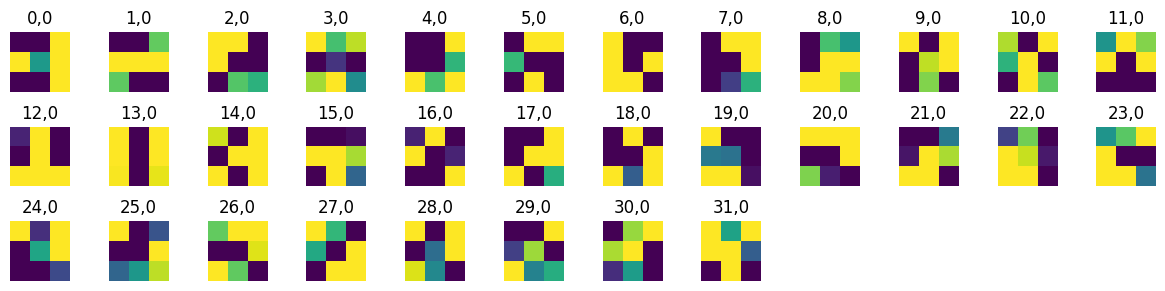

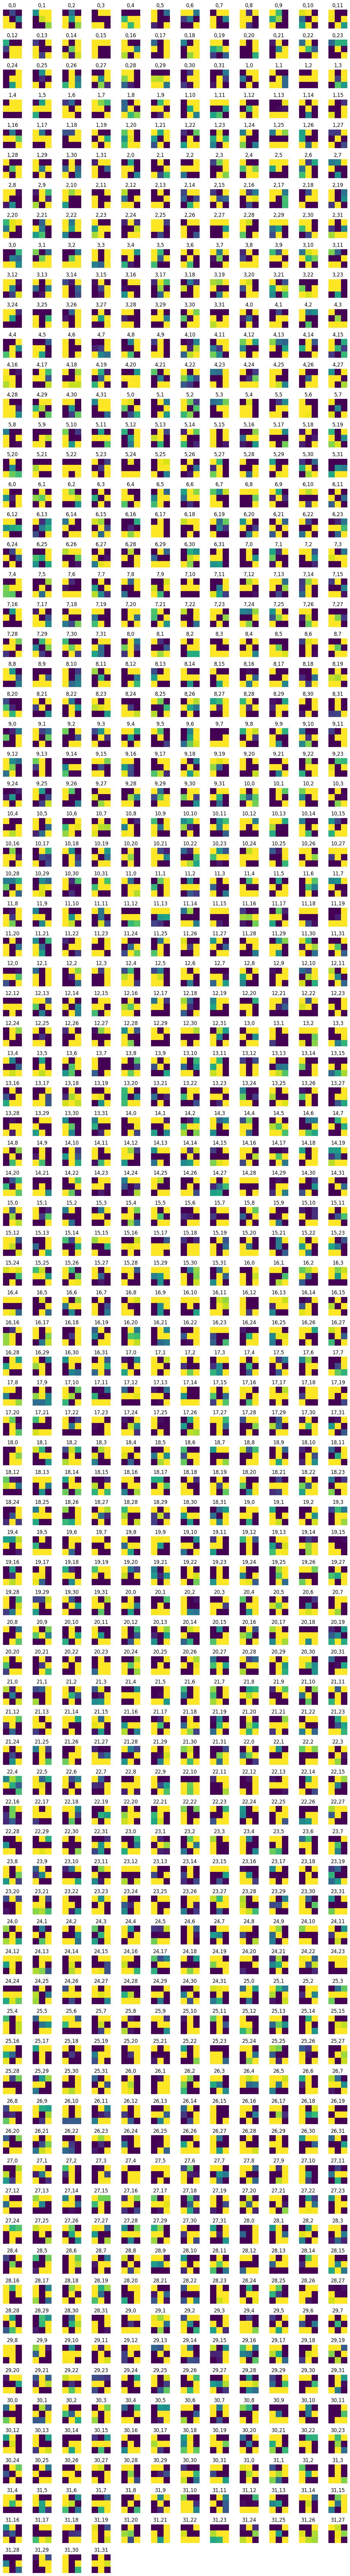

In [24]:
def plot_filters_single_channel_big(t):
    nrows = t.shape[0] * t.shape[2]
    ncols = t.shape[1] * t.shape[3]
    npimg = np.array(t.numpy(), np.float32)
    npimg = npimg.transpose((0, 2, 1, 3))
    npimg = npimg.ravel().reshape(nrows, ncols)
    npimg = npimg.T
    fig, ax = plt.subplots(figsize=(ncols / 10, nrows / 200))
    imgplot = sns.heatmap(npimg, xticklabels=False, yticklabels=False, cmap='gray', ax=ax, cbar=False)


def plot_filters_single_channel(t):
    nplots = t.shape[0] * t.shape[1]
    ncols = 12
    nrows = 1 + nplots // ncols
    npimg = np.array(t.numpy(), np.float32)
    count = 0
    fig = plt.figure(figsize=(ncols, nrows))
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            count += 1
            ax1 = fig.add_subplot(nrows, ncols, count)
            npimg = np.array(t[i, j].numpy(), np.float32)
            npimg = (npimg - np.mean(npimg)) / np.std(npimg)
            npimg = np.minimum(1, np.maximum(0, (npimg + 0.5)))
            ax1.imshow(npimg)
            ax1.set_title(str(i) + ',' + str(j))
            ax1.axis('off')
            ax1.set_xticklabels([])
            ax1.set_yticklabels([])
    plt.tight_layout()
    plt.show()


def plot_filters_multi_channel(t):
    num_kernels = t.shape[0]
    num_cols = 12
    num_rows = num_kernels
    fig = plt.figure(figsize=(num_cols, num_rows))
    for i in range(t.shape[0]):
        ax1 = fig.add_subplot(num_rows, num_cols, i + 1)
        npimg = np.array(t[i].numpy(), np.float32)
        npimg = (npimg - np.mean(npimg)) / np.std(npimg)
        npimg = np.minimum(1, np.maximum(0, (npimg + 0.5)))
        npimg = npimg.transpose((1, 2, 0))
        ax1.imshow(npimg)
        ax1.axis('off')
        ax1.set_title(str(i))
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
    plt.savefig('kernels.png', dpi=100)
    plt.tight_layout()
    plt.show()


def plot_weights(layer, single_channel=True, collated=False):
    if isinstance(layer, nn.Conv2d):
        weight_tensor = layer.weight.data
        if single_channel:
            if collated:
                plot_filters_single_channel_big(weight_tensor.cpu())
            else:
                plot_filters_single_channel(weight_tensor.cpu())
        else:
            if weight_tensor.shape[1] == 3:
                plot_filters_multi_channel(weight_tensor.cpu())
            else:
                print("Can only plot weights with three channels with single channel = False")
    else:
        print("Can only visualize layers which are convolutional")


# Visualizar feature maps (filtros) das camadas convolucionais
plot_weights(model.layer1[0], single_channel=True)
plot_weights(model.layer2[0], single_channel=True)


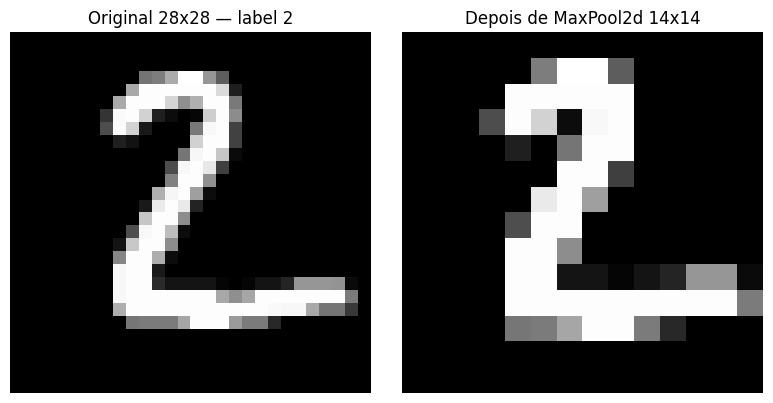

In [25]:
# Aplicar o max pooling
images, labels = next(iter(test_dl))
img = images[0:1].to(device)

pool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = pool(img)

original = img.detach().cpu()[0, 0]
pooled_img = pooled.detach().cpu()[0, 0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title(f"Original 28x28 — label {labels[0].item()}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pooled_img, cmap='gray')
plt.title("Depois de MaxPool2d 14x14")
plt.axis('off')

plt.tight_layout()
plt.show()


torch.Size([1, 1, 28, 28])
torch.float32


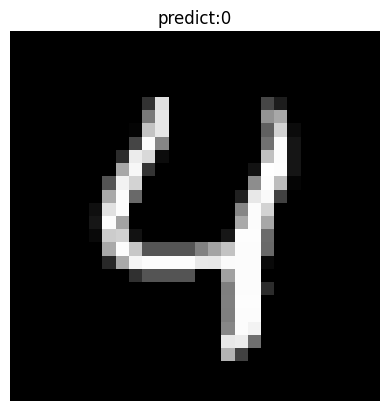

pred: 0
0
torch.Size([32, 1, 28, 28])


In [26]:
def show_batch_images(model, dataloader, num_image):
    imagens, label = next(iter(test_dl))
    pred = make_prediction(model, imagens[3])
    print("pred:", pred)
    return imagens, pred

images, pred = show_batch_images(model, test_dl, 1)
print(pred)
print(images.shape)


In [27]:
def get_conv_layers(model):
    conv_layers = list()
    model_children = list(model.children())
    for child in model_children:
        if type(child) == Conv2d:
            conv_layers.append(child)
        elif type(child) == Sequential:
            for layer in child.children():
                if type(layer) == Conv2d:
                    conv_layers.append(layer)
    return conv_layers


def get_conv_pool_layers(model):
    conv_layers = list()
    model_children = list(model.children())
    for child in model_children:
        if type(child) == Conv2d or type(child) == MaxPool2d:
            conv_layers.append(child)
        elif type(child) == Sequential:
            for layer in child.children():
                if type(layer) == Conv2d or (type(layer) == MaxPool2d):
                    conv_layers.append(layer)
    return conv_layers


conv_layers = get_conv_pool_layers(model)
print(conv_layers)
print(len(conv_layers))


[Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1)), MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False), Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1)), MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)]
4


In [28]:
def percorrer_conv_layers(images, conv_layers):
    images = images.to(device)
    results = [conv_layers[0](images)]
    for i in range(1, len(conv_layers)):
        results.append(conv_layers[i](results[-1]))
    outputs = results
    return outputs


outputs = percorrer_conv_layers(images, conv_layers)
print(f"Obtiveram-se {len(outputs)} tensores com o shape:")
for i in range(len(outputs)):
    print(f"    Layer {i} - {outputs[i].shape}")


Obtiveram-se 4 tensores com o shape:
    Layer 0 - torch.Size([32, 32, 26, 26])
    Layer 1 - torch.Size([32, 32, 13, 13])
    Layer 2 - torch.Size([32, 32, 11, 11])
    Layer 3 - torch.Size([32, 32, 5, 5])


Layer  1


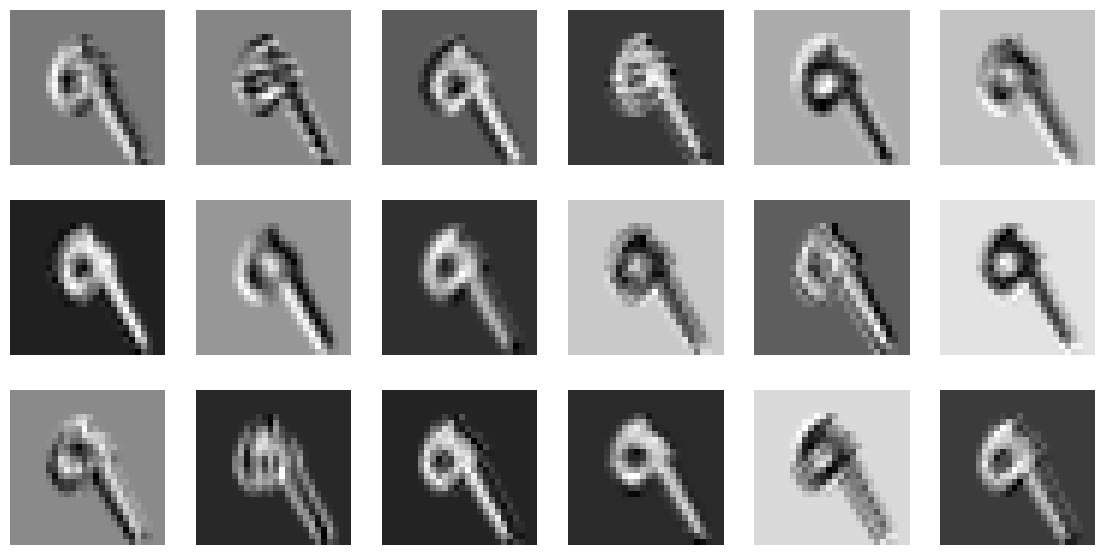

Layer  2


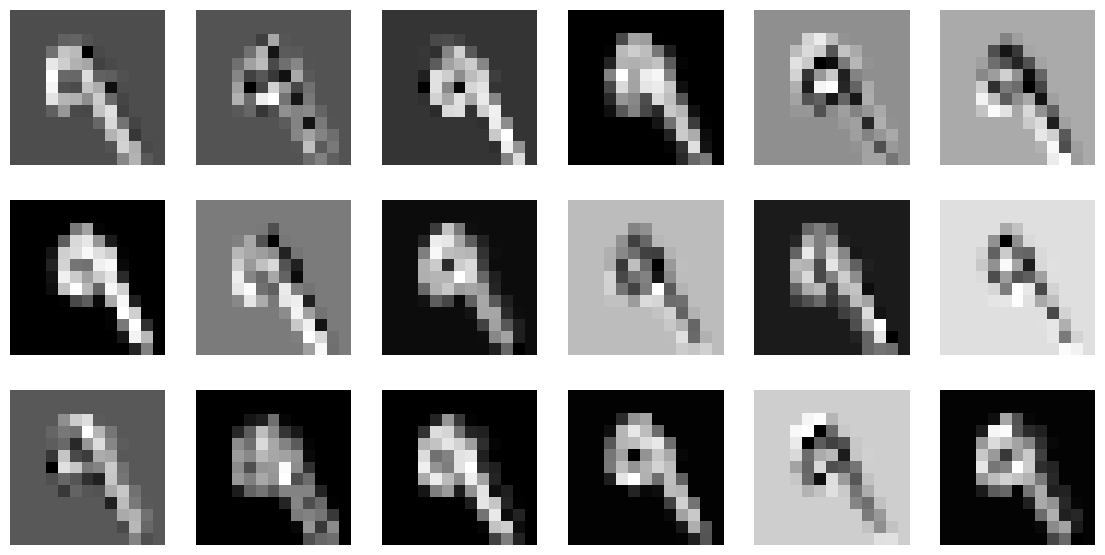

Layer  3


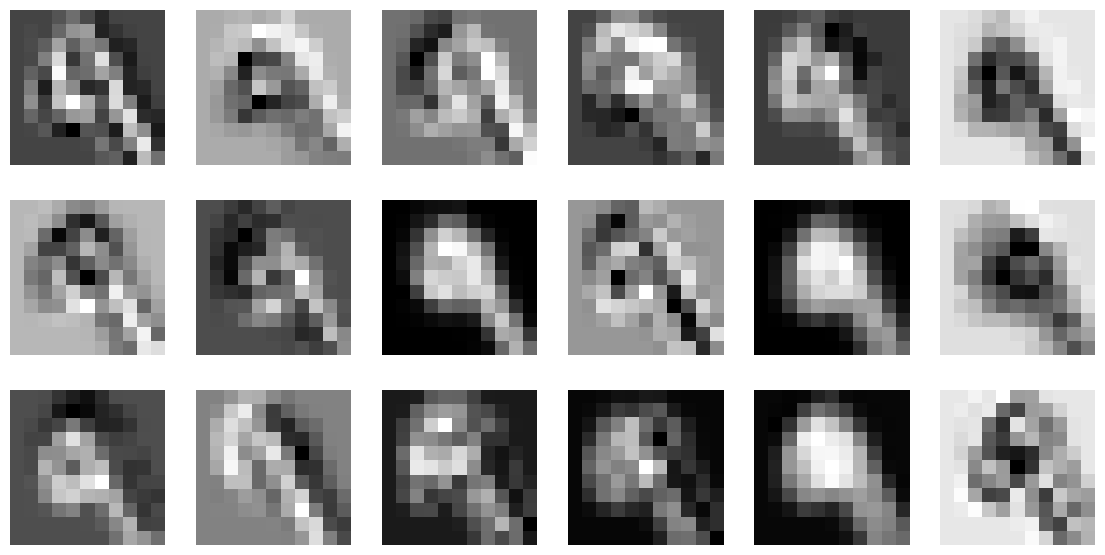

Layer  4


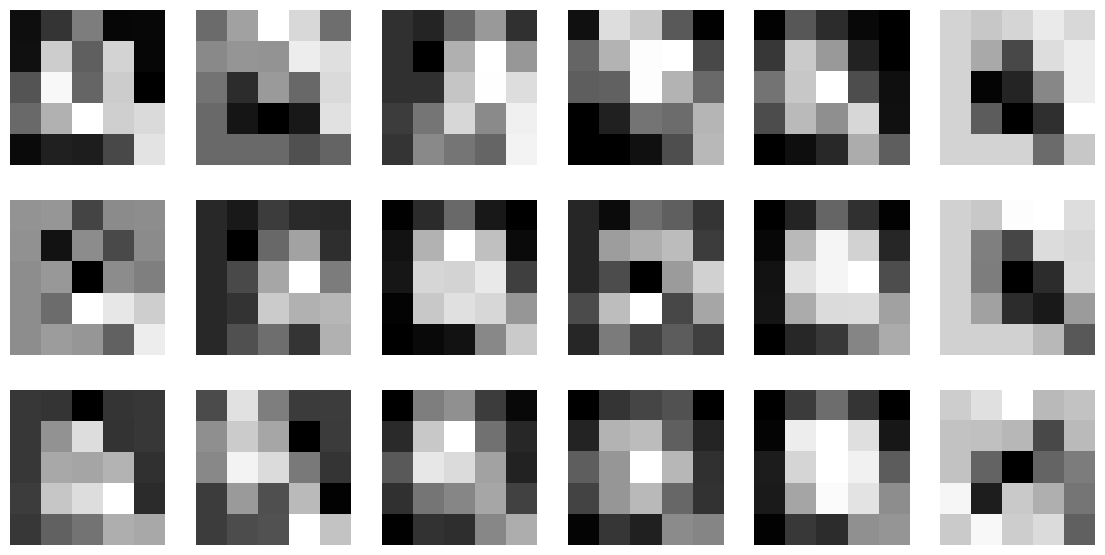

In [29]:
def visualize_featureMaps_partial(outputs, num_imagem):
    for num_layer in range(len(outputs)):
        plt.figure(figsize=(14, 7))
        layer_viz = outputs[num_layer][num_imagem, :, :, :]
        layer_viz = layer_viz.data
        print("Layer ", num_layer + 1)
        for i, filter in enumerate(layer_viz):
            if i == 18:
                break
            plt.subplot(3, 6, i + 1)
            plt.imshow(filter.cpu(), cmap='gray')
            plt.axis("off")
        plt.show()
        plt.close()


visualize_featureMaps_partial(outputs, 6)
